In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/Project/fertilizer_recommendation_enhanced.csv"

In [ ]:
!pip install pytorch-tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.4 MB/s eta 0:00:00


In [ ]:
!pip install shap

In [ ]:
!pip install imbalanced-learn

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/drive/MyDrive/placement_dataset.csv
/content/drive/MyDrive/placementfilledcat.csv
/content/drive/MyDrive/Colab/placement_dataset.csv
/content/drive/MyDrive/Colab/placement_predict_50k_adjusted.csv
/content/drive/MyDrive/Colab/age_insurance.csv
/content/drive/MyDrive/Colab/placement_filled.csv
/content/drive/MyDrive/Colab/CGPA_Regression_Dataset.csv
/content/drive/MyDrive/Colab/fertilizer_recommendation_enhanced.csv
/content/drive/MyDrive/Colab/Titanic/gender_submission.csv
/content/drive/MyDrive/Colab/Titanic/test.csv
/content/drive/MyDrive/Colab/Titanic/train.csv


In [ ]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Colab/fertilizer_recommendation_enhanced.csv"

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(10000, 30)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,...,Soil_Health_Score,Disease_Risk,Water_Availability,Weather_Condition,Farmer_Experience,Land_Size,Market_Demand,Expected_Yield,NPK_Ratio,Fertilizer_Cost
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,...,63.00,Medium,High,Rainy,15,5.20,Low,1.44,61:44:84,950.0
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,...,44.33,Low,High,Cloudy,14,14.89,Medium,4.61,59:56:18,350.0
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,...,61.00,Medium,High,Cloudy,19,12.48,High,7.97,43:21:119,350.0
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,...,56.00,Low,High,Sunny,25,18.58,Low,1.99,88:46:34,950.0
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,...,85.00,Low,High,Sunny,13,9.39,Low,7.96,104:53:98,700.0


In [ ]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  object 
 12  Crop_Growth_Stage            10000 non-null  object 
 13  Season           

In [ ]:
!ls "/content/drive/MyDrive/Colab"

 age_insurance.csv			  placement_dataset.csv
'archive (6).zip'			  placement_filled.csv
 binary_logistic_plot.png		  placement_predict_50k_adjusted.csv
 CGPA_Regression_Dataset.csv		  Titanic
 fertilizer_recommendation_enhanced.csv   titanic.zip


In [ ]:
df.isnull().sum()

,0
Soil_Type,0
Soil_pH,0
Soil_Moisture,0
Organic_Carbon,0
Electrical_Conductivity,0
Nitrogen_Level,0
Phosphorus_Level,0
Potassium_Level,0
Temperature,0
Humidity,0


In [ ]:
df = df.dropna()

In [ ]:
print(df.columns)

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level',
       'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type',
       'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop',
       'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season',
       'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk',
       'Water_Availability', 'Weather_Condition', 'Farmer_Experience',
       'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio',
       'Fertilizer_Cost'],
      dtype='object')


In [ ]:
target = "Recommended_Fertilizer"

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [ ]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 29)
(2000, 29)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)

print(X_train.shape)

(17367, 29)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9825


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       199
           1       1.00      1.00      1.00       584
           2       1.00      1.00      1.00       282
           3       0.90      0.82      0.86       128
           4       0.52      0.68      0.59        37
           5       1.00      1.00      1.00       620
           6       1.00      1.00      1.00       150

    accuracy                           0.98      2000
   macro avg       0.92      0.93      0.92      2000
weighted avg       0.98      0.98      0.98      2000



In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.9825


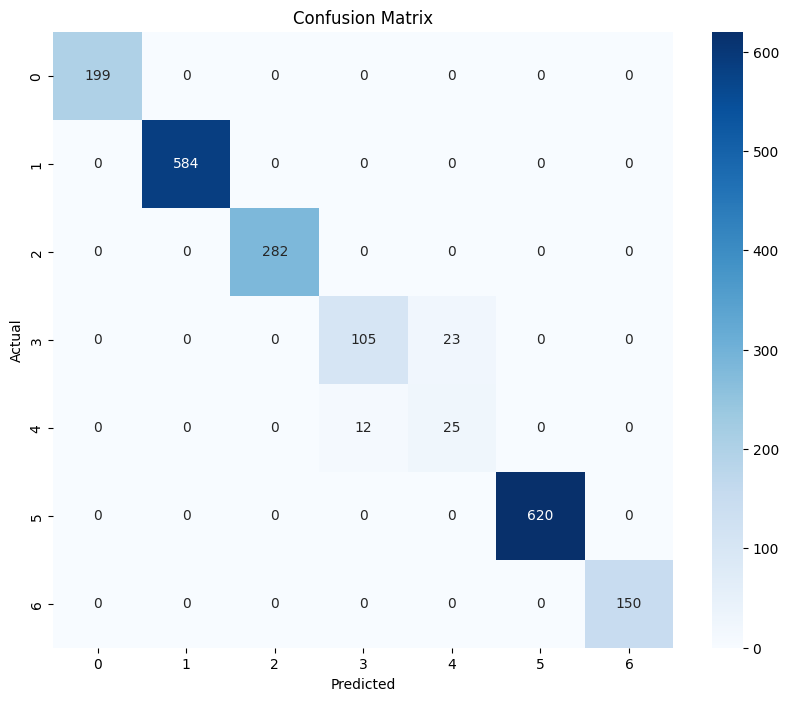

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

                        Feature  Importance
28              Fertilizer_Cost    0.355054
5                Nitrogen_Level    0.106882
1                       Soil_pH    0.104976
6              Phosphorus_Level    0.097766
7               Potassium_Level    0.082009
12            Crop_Growth_Stage    0.073171
19            Soil_Health_Score    0.036365
27                    NPK_Ratio    0.021758
3                Organic_Carbon    0.008749
17  Fertilizer_Used_Last_Season    0.007608
24                    Land_Size    0.007413
23            Farmer_Experience    0.007049
18            Yield_Last_Season    0.006949
10                     Rainfall    0.006861
9                      Humidity    0.006838


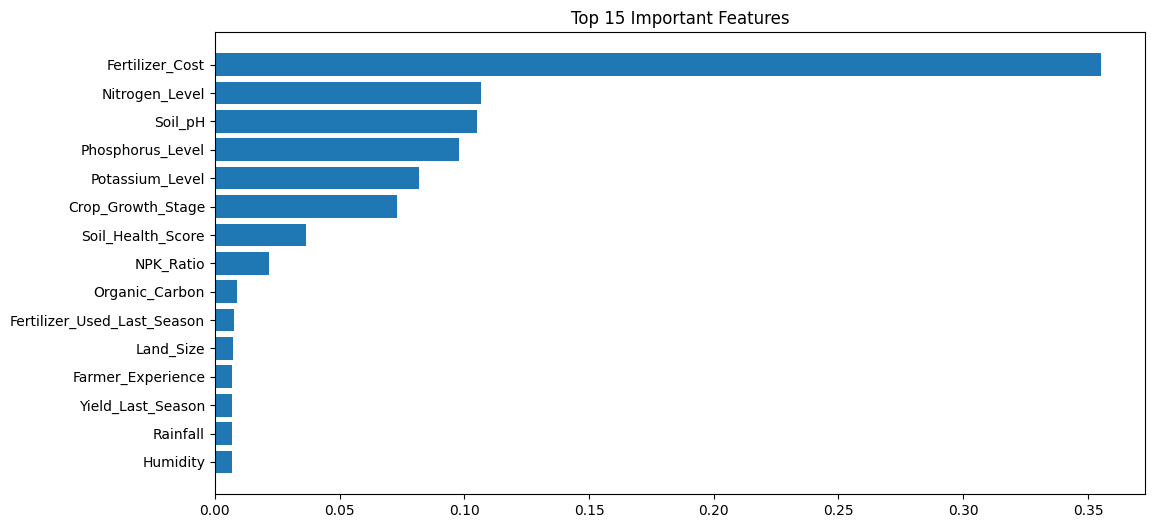

In [ ]:
plt.figure(figsize=(12,6))

plt.barh(
    feature_importance['Feature'][:15],
    feature_importance['Importance'][:15]
)

plt.gca().invert_yaxis()
plt.title("Top 15 Important Features")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, "fertilizer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model Saved")

Model Saved


In [ ]:
from google.colab import files

files.download("fertilizer_model.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install shap

In [ ]:
import shap

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test)

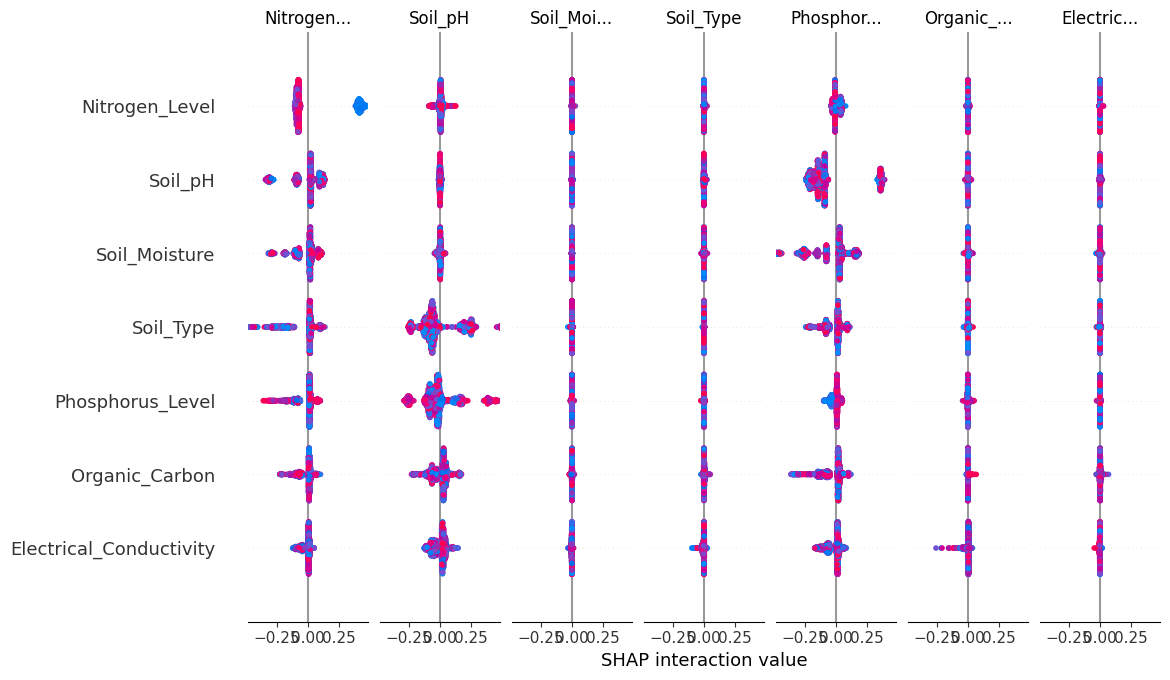

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [ ]:
sample = X_test[0].reshape(1,-1)

prediction = rf.predict(sample)

print(
    "Predicted Fertilizer:",
    prediction[0]
)

Predicted Fertilizer: 0


In [ ]:
fertilizer_name = label_encoders[
    'Recommended_Fertilizer'
].inverse_transform(prediction)

print(fertilizer_name[0])

Compost


In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.9825


In [ ]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [ ]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

XGBoost Accuracy: 0.9815


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

XGBoost Accuracy: 0.9815


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print(
    "XGBoost Accuracy:",
    accuracy_score(y_test, xgb_pred)
)

XGBoost Accuracy: 0.9815


In [ ]:
import joblib

joblib.dump(label_encoders, "label_encoders.pkl")

['label_encoders.pkl']

In [ ]:
def predict_fertilizer(input_data):

    input_df = pd.DataFrame(
        [input_data]
    )

    for col in label_encoders:

        if col in input_df.columns:

            input_df[col] = label_encoders[
                col
            ].transform(
                input_df[col]
            )

    input_scaled = scaler.transform(
        input_df
    )

    prediction = rf.predict(
        input_scaled
    )

    fertilizer = label_encoders[
        'Recommended_Fertilizer'
    ].inverse_transform(
        prediction
    )

    return fertilizer[0]

In [ ]:
print(df['Region'].unique())

[3 0 4 1 2]


In [ ]:
df['Region'].unique()

array([3, 0, 4, 1, 2])

In [ ]:
label_encoders['Region'].classes_

array(['Central', 'East', 'North', 'South', 'West'], dtype=object)

In [2]:
from sklearn.metrics import accuracy_score


In [3]:
pred = rf.predict(X_test)

NameError: name 'rf' is not defined

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model trained successfully")

NameError: name 'X_train' is not defined

In [5]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

NameError: name 'df' is not defined

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

csv_path = "/content/drive/MyDrive/Colab/fertilizer_recommendation_enhanced.csv"

df = pd.read_csv(csv_path)

print(df.shape)
df.head()

(10000, 30)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,...,Soil_Health_Score,Disease_Risk,Water_Availability,Weather_Condition,Farmer_Experience,Land_Size,Market_Demand,Expected_Yield,NPK_Ratio,Fertilizer_Cost
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,...,63.00,Medium,High,Rainy,15,5.20,Low,1.44,61:44:84,950.0
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,...,44.33,Low,High,Cloudy,14,14.89,Medium,4.61,59:56:18,350.0
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,...,61.00,Medium,High,Cloudy,19,12.48,High,7.97,43:21:119,350.0
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,...,56.00,Low,High,Sunny,25,18.58,Low,1.99,88:46:34,950.0
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,...,85.00,Low,High,Sunny,13,9.39,Low,7.96,104:53:98,700.0


In [8]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [9]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)

(8000, 29)


In [11]:
print(df.shape)

(10000, 30)


In [12]:
print(df.columns.tolist())

['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Temperature', 'Humidity', 'Rainfall', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Previous_Crop', 'Region', 'Fertilizer_Used_Last_Season', 'Yield_Last_Season', 'Recommended_Fertilizer', 'Soil_Health_Score', 'Disease_Risk', 'Water_Availability', 'Weather_Condition', 'Farmer_Experience', 'Land_Size', 'Market_Demand', 'Expected_Yield', 'NPK_Ratio', 'Fertilizer_Cost']


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for col in X.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [17]:
from sklearn.metrics import accuracy_score

pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.9815


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       199
           1       1.00      1.00      1.00       584
           2       1.00      1.00      1.00       282
           3       0.80      0.95      0.87       128
           4       0.50      0.19      0.27        37
           5       1.00      1.00      1.00       620
           6       1.00      1.00      1.00       150

    accuracy                           0.98      2000
   macro avg       0.90      0.88      0.88      2000
weighted avg       0.98      0.98      0.98      2000



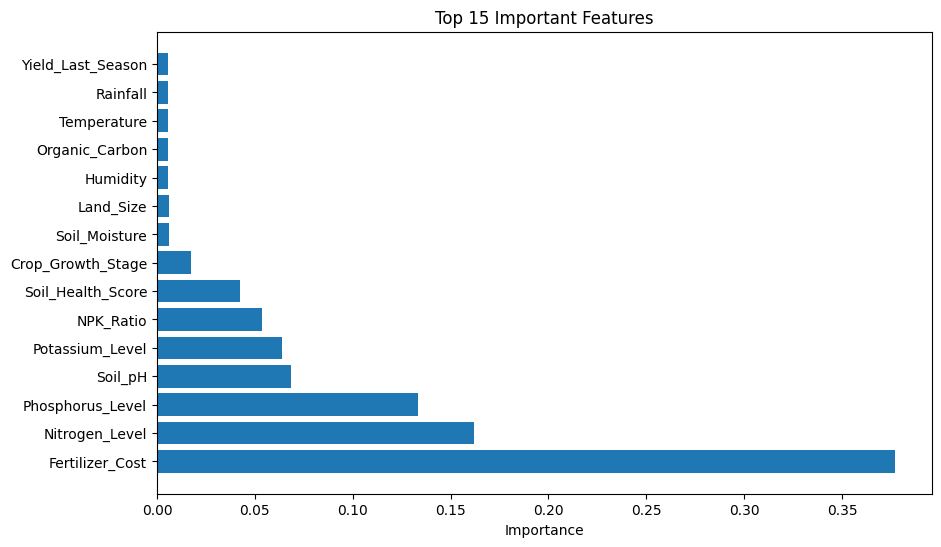

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp = feat_imp.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'][:15],
         feat_imp['Importance'][:15])
plt.xlabel("Importance")
plt.title("Top 15 Important Features")
plt.show()

<Figure size 800x600 with 0 Axes>

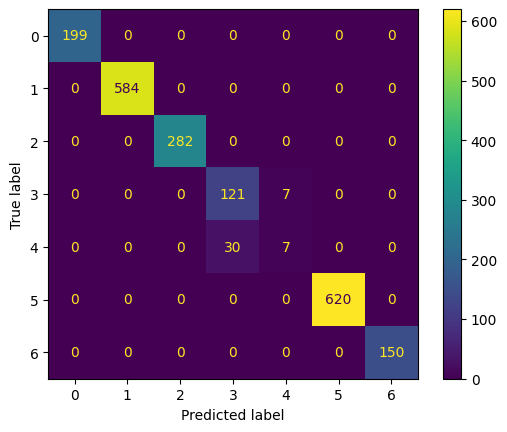

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(8,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [21]:
import joblib

joblib.dump(rf, "fertilizer_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

print("All files saved")

All files saved


In [22]:
from google.colab import files

files.download("fertilizer_model.pkl")
files.download("scaler.pkl")
files.download("label_encoders.pkl")
files.download("target_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>